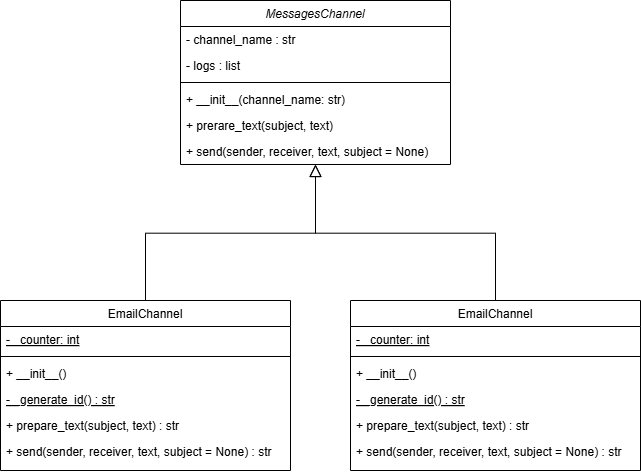

In [6]:
#1
from abc import ABC, abstractmethod

class MessagesChannel(ABC):
    def __init__(self, channel_name):
        self.channel_name = channel_name
        self.logs = []

    @abstractmethod
    def prepare_text(self, subject, text):
        pass

    @abstractmethod
    def send(self, sender, reciever, text, subject = None):
        pass

class EmailChannel(MessagesChannel):
    _counter = 0

    def __init__(self):
        super().__init__("Email" )

    @staticmethod
    def _generate_id():
        EmailChannel._counter += 1
        return f'Email_{EmailChannel._counter}'

    def prepare_text(self, subject, text):
        return (f'Subject: {subject}\n'
                f'{text}')

    def send(self, sender, reciever, text, subject = None):
        if subject is None:
            subject = "No subject"

        if text is None:
            text = "No text"

        message_id = self._generate_id()
        prepared_text = self.prepare_text(subject, text)

        self.logs.append({
            'id' : message_id,
            'channel' : self.channel_name,
            'sender' : sender,
            'reciever' : reciever,
            'subject and text' : prepared_text
        })

        print(f'Отправлено {message_id}:\n'
              f' {sender} -> {reciever}\n'
              f' {prepared_text}')
        return message_id

class SMSChannel(MessagesChannel):
    _counter = 0

    def __init__(self):
        super().__init__("SMS")
        self.logs = []

    @staticmethod
    def _generate_id():
        SMSChannel._counter += 1
        return f'SMS_{SMSChannel._counter}'

    def prepare_text(self, subject, text):
        if len(text) > 160:
            print("Сообщение содержит больше символов, чем допустимо.\n"
                  "Отправлены первые 160 символов")
        return (f'{text[:160]}')

    def send(self, sender, reciever, text, subject = None):
        if text is None:
            text = "No text"

        message_id = self._generate_id()
        prepared_text = self.prepare_text(subject, text)

        self.logs.append({
            'id': message_id,
            'channel': self.channel_name,
            'sender': sender,
            'reciever': reciever,
            'text': prepared_text
        })

        print(f'Отправлено {message_id}:\n'
              f' {sender} -> {reciever}\n'
              f' {prepared_text}')
        return message_id






email_work = EmailChannel()
email_personal = EmailChannel()
email_spam = EmailChannel()

email_work.send("alice@company.com", "bob@company.com",
                "Пришли отчет за май", subject="Отчет")

email_work.send("bob@company.com", "alice@company.com",
                "Отчет готов", subject="Re: Отчет")

email_personal.send("ivan@mail.ru", "petr@mail.ru",
                    "Пойдем гулять?", subject="Планы на выходные")

email_personal.send("petr@mail.ru", "ivan@mail.ru",
                    "Давай, во сколько?", subject="Re: Планы на выходные")

email_spam.send("newsletter@site.com", "user1@mail.com",
                "Купите нашу новую крутую штуку!!!", subject=None)

email_spam.send("newsletter@site.com", "user2@mail.com",
                "Скидка 50% только сегодня!", subject=None)

email_work.send("system@company.com", "admin@company.com",
                None, subject="Ошибка в системе")

print(f'Логи email:{email_work.logs 
                    + email_personal.logs 
                    + email_spam.logs} \n')





sms = SMSChannel()
sms.send("+79001234567", "+79991112233", "Купи хлеба")
print()
sms.send("+79001234567", "+78883334455", "А" * 200, subject="Неважно")

print(f'\nЛоги sms:{sms.logs}')

Отправлено Email_1:
 alice@company.com -> bob@company.com
 Subject: Отчет
Пришли отчет за май
Отправлено Email_2:
 bob@company.com -> alice@company.com
 Subject: Re: Отчет
Отчет готов
Отправлено Email_3:
 ivan@mail.ru -> petr@mail.ru
 Subject: Планы на выходные
Пойдем гулять?
Отправлено Email_4:
 petr@mail.ru -> ivan@mail.ru
 Subject: Re: Планы на выходные
Давай, во сколько?
Отправлено Email_5:
 newsletter@site.com -> user1@mail.com
 Subject: No subject
Купите нашу новую крутую штуку!!!
Отправлено Email_6:
 newsletter@site.com -> user2@mail.com
 Subject: No subject
Скидка 50% только сегодня!
Отправлено Email_7:
 system@company.com -> admin@company.com
 Subject: Ошибка в системе
No text
Логи email:[{'id': 'Email_1', 'channel': 'Email', 'sender': 'alice@company.com', 'reciever': 'bob@company.com', 'subject and text': 'Subject: Отчет\nПришли отчет за май'}, {'id': 'Email_2', 'channel': 'Email', 'sender': 'bob@company.com', 'reciever': 'alice@company.com', 'subject and text': 'Subject: Re:

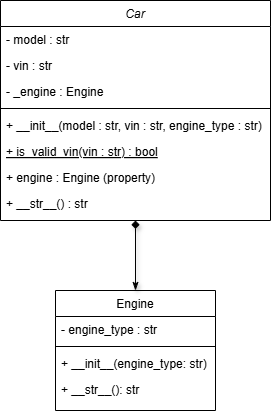

In [7]:
#2
class Engine:
    def __init__(self, engine_type):
        self.engine_type = engine_type

    def __str__(self):
        return f"Engine type = {self.engine_type}"

class Car:
    @staticmethod
    def is_valid_vin(vin):
        if len(vin) != 17:
            return False

        vin_upper = vin.upper()

        for char in vin_upper:
            if not char.isalnum():
                return False
            if char.isalpha() and char not in "ABCDEFGHJKLMNPRSTUVWXYZ":
                return False
            if char in 'IOQ':
                return False

        return True

    def __init__(self, model, vin, engine_type):
        if not Car.is_valid_vin(vin):
            raise ValueError(f"Невалидный VIN: {vin}")
        self.model = model
        self.vin = vin
        self._engine = Engine(engine_type)

    @property
    def engine(self):
        return self._engine

    def __str__(self):
        return f"Car {self.model}, VIN={self.vin}, engine={self.engine}"


tesla = Car("Tesla Model S", "5YJSA1E26HF123456", "electric")
bmw = Car("BMW X5", "WBAKS410X0J123456", "petrol")

print(Car.is_valid_vin("123"))
print(Car.is_valid_vin("5YJSA1E26HF123456"))
print(Car.is_valid_vin("5YJSA1E26HF12345Q"))


False
True
False


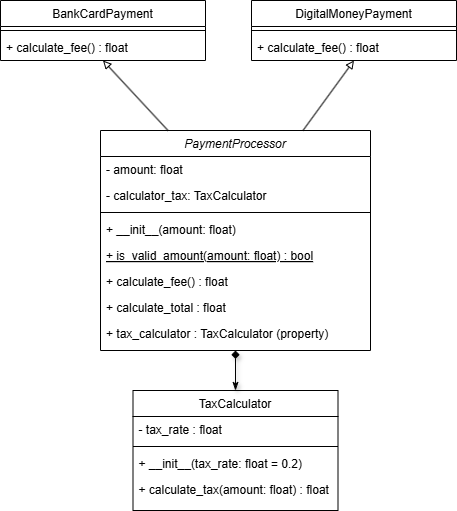

In [11]:
class TaxCalculator:

    def __init__(self, tax_rate = 0.2):
        self.tax_rate = tax_rate

    def calculate_tax(self, amount):
        return amount * self.tax_rate


class PaymentProcessor:
    @staticmethod
    def is_valid_amount(amount):
        return 0 < amount <= 1000000

    def __init__(self, amount):
        if not self.is_valid_amount(amount):
            raise ValueError("Недопустимая сумма")
        self.amount = amount
        self.calculator_tax = TaxCalculator()

    def calculate_fee(self):
        pass

    def calculate_total(self):
        return self.amount + self.calculate_fee() + self.tax_calculator.calculate_tax(self.amount)

    @property
    def tax_calculator(self):
        return self.calculator_tax

class BankCardPayment(PaymentProcessor):
    def calculate_fee(self):
        return self.amount * 0.015

class DigitalMoneyPayment(PaymentProcessor):
    def calculate_fee(self):
        return self.amount * 0.025

card = BankCardPayment(350)
digital = DigitalMoneyPayment(250)

print(f"Карта: сумма={card.amount}, комиссия={card.calculate_fee()}, налог={card.tax_calculator.calculate_tax(card.amount)}, итого={card.calculate_total()}")
print(f"Электронные: сумма={digital.amount}, комиссия={digital.calculate_fee()}, налог={digital.tax_calculator.calculate_tax(card.amount)}, итого={digital.calculate_total()}")

Карта: сумма=350, комиссия=5.25, налог=70.0, итого=425.25
Электронные: сумма=250, комиссия=6.25, налог=70.0, итого=306.25
